# setup & imports

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    for parent in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (parent / 'src').exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import sktime
import torch
import numpy as np
import matplotlib.pyplot as plt
print(f'sktime version: {sktime.__version__}')
print(f'torch version: {torch.__version__}')

sktime version: 0.40.1
torch version: 2.11.0+cpu


# load data

Training: 3601 samples x 1 channel x 500 timesteps
Test: 1320 samples


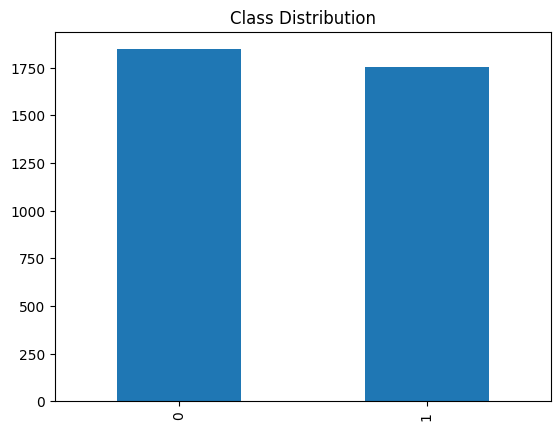

In [3]:
from src.data_loader import load_ford_a

X_train, y_train, X_test, y_test = load_ford_a()
print(f'Training: {X_train.shape[0]} samples x {X_train.shape[1]} channel x {X_train.shape[2]} timesteps')
print(f'Test: {X_test.shape[0]} samples')

import pandas as pd
counts = pd.Series(y_train).value_counts()
counts.plot(kind='bar', title='Class Distribution')
plt.show()

# visualize samples

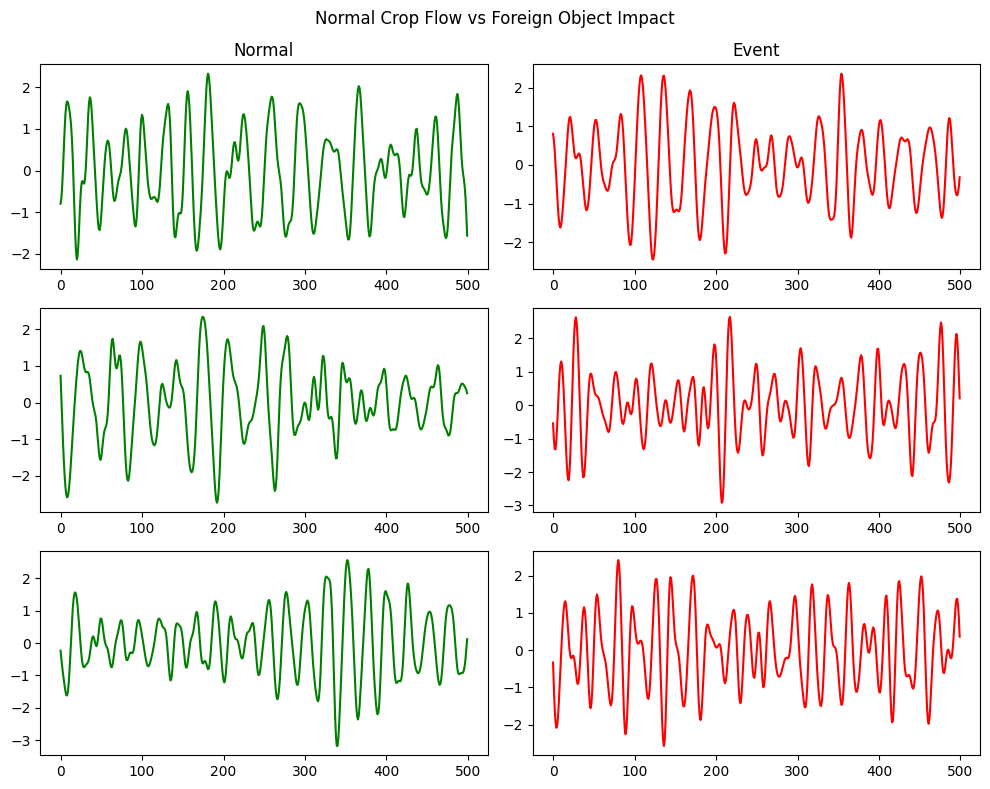

In [4]:
normal_samples = X_train[y_train == 0][:3]
event_samples = X_train[y_train == 1][:3]

fig, axes = plt.subplots(3, 2, figsize=(10, 8))
fig.suptitle('Normal Crop Flow vs Foreign Object Impact')
for i in range(3):
    axes[i, 0].plot(normal_samples[i, 0, :], color='green')
    if i == 0: axes[i, 0].set_title('Normal')
    axes[i, 1].plot(event_samples[i, 0, :], color='red')
    if i == 0: axes[i, 1].set_title('Event')
plt.tight_layout()
plt.show()

# train mlp classifier

In [5]:
from src.models.sktime_classifiers import build_mlp_classifier
clf = build_mlp_classifier()
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    clf.fit(X_train, y_train)

Epoch 1: Loss: 0.6344622962374603
Epoch 2: Loss: 0.554297081631633
Epoch 3: Loss: 0.4927404715753762
Epoch 4: Loss: 0.4400407744950689
Epoch 5: Loss: 0.38769806981235083
Epoch 6: Loss: 0.33444093734611124
Epoch 7: Loss: 0.31148441085440987
Epoch 8: Loss: 0.2850627909018864
Epoch 9: Loss: 0.25508005050344773
Epoch 10: Loss: 0.23889434912159063
Epoch 11: Loss: 0.213094634776718
Epoch 12: Loss: 0.19926784159032593
Epoch 13: Loss: 0.192588552880694
Epoch 14: Loss: 0.17846426398988371
Epoch 15: Loss: 0.15775164599319266
Epoch 16: Loss: 0.15605547878912734
Epoch 17: Loss: 0.15867242704018636
Epoch 18: Loss: 0.14710498712719955
Epoch 19: Loss: 0.12798787292625907
Epoch 20: Loss: 0.1371694493109377
Epoch 21: Loss: 0.12755779550461416
Epoch 22: Loss: 0.12095356979757646
Epoch 23: Loss: 0.11229774781525448
Epoch 24: Loss: 0.12996921345253606
Epoch 25: Loss: 0.11450236024409331
Epoch 26: Loss: 0.0967214909463681
Epoch 27: Loss: 0.10955646192959863
Epoch 28: Loss: 0.09818530880662703
Epoch 29: Los

# train tsf baseline

In [6]:
from src.models.sktime_classifiers import build_tsf_baseline
tsf = build_tsf_baseline()
tsf.fit(X_train, y_train)

,min_interval,3
,n_estimators,200
,inner_series_length,None
,n_jobs,1
,random_state,42


# evaluate both models

In [7]:
from src.evaluation.metrics import compute_classification_metrics
y_pred_clf = clf.predict(X_test)
y_proba_clf = clf.predict_proba(X_test)[:, 1]
metrics_clf = compute_classification_metrics(y_test, y_pred_clf, y_proba_clf)
print('MLP Classification Report:')
print(metrics_clf['classification_report'])

y_pred_tsf = tsf.predict(X_test)
y_proba_tsf = tsf.predict_proba(X_test)[:, 1]
metrics_tsf = compute_classification_metrics(y_test, y_pred_tsf, y_proba_tsf)
print('TSF Classification Report:')
print(metrics_tsf['classification_report'])

MLP Classification Report:
                precision    recall  f1-score   support

        Normal       0.83      0.80      0.81       681
Foreign Object       0.79      0.83      0.81       639

      accuracy                           0.81      1320
     macro avg       0.81      0.81      0.81      1320
  weighted avg       0.81      0.81      0.81      1320

TSF Classification Report:
                precision    recall  f1-score   support

        Normal       0.81      0.83      0.82       681
Foreign Object       0.81      0.79      0.80       639

      accuracy                           0.81      1320
     macro avg       0.81      0.81      0.81      1320
  weighted avg       0.81      0.81      0.81      1320



# roc curves

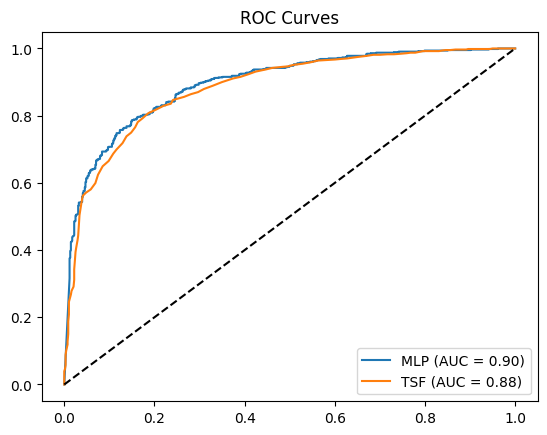

In [8]:
from sklearn.metrics import roc_curve, auc
fpr_clf, tpr_clf, _ = roc_curve(y_test, y_proba_clf)
roc_auc_clf = auc(fpr_clf, tpr_clf)

fpr_tsf, tpr_tsf, _ = roc_curve(y_test, y_proba_tsf)
roc_auc_tsf = auc(fpr_tsf, tpr_tsf)

plt.figure()
plt.plot(fpr_clf, tpr_clf, label=f'MLP (AUC = {roc_auc_clf:.2f})')
plt.plot(fpr_tsf, tpr_tsf, label=f'TSF (AUC = {roc_auc_tsf:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.show()

# save models

In [9]:
import pickle
from src.config import MODELS_DIR
with open(MODELS_DIR / 'sktime_mlp_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)